In [2]:
import json

list_relations  = {
"FormOf" : "[SUBJECT] is an inflected form of [OBJECT]; [OBJECT] is the root word of [SUBJECT]" ,
"IsA" : "[SUBJECT] is a subtype or a specific instance of [OBJECT]" ,
"CanBe" : "[SUBJECT] is possibly [OBJECT]",
"PartOf" : "[SUBJECT] is a part of [OBJECT]" ,
"HasA" : "[OBJECT] belongs to [SUBJECT]" ,
"Contains" : "[SUBJECT] contains [OBJECT]",
"UsedFor" : "[SUBJECT] is used for [OBJECT]; the purpose of [SUBJECT] is [OBJECT]" ,
"CapableOf" : "Something that [SUBJECT] can typically do is [OBJECT]" ,
"AtLocation" : "[SUBJECT] is located at [OBJECT], [SUBJECT] can be an event taking place at [OBJECT]" ,
"Causes" : "[SUBJECT] and [OBJECT] are events, and [SUBJECT] causes [OBJECT]" ,
"HasSubevent" : "[SUBJECT] and [OBJECT] are events, and [OBJECT] happens as a subevent of [SUBJECT]" ,
"HasPrerequisite" : "In order for [SUBJECT] to happen, [OBJECT] needs to happen; [OBJECT] is a dependency of [SUBJECT]" ,
"HasProperty" : "[SUBJECT] has [OBJECT] as a property; [SUBJECT] can be described as [OBJECT]" ,
"MotivatedByGoal" : "Someone does [SUBJECT] because they want result [OBJECT]; [SUBJECT] is a step toward accomplishing the goal [OBJECT]" ,
"CreatedBy" : "[OBJECT] is a process or agent that creates [SUBJECT]" ,
"Synonym" : "[SUBJECT] and [OBJECT] have very similar meanings. Symmetric" ,
"Antonym" : "[SUBJECT] and [OBJECT] are opposites in some relevant way" ,
"SymbolOf" : "[SUBJECT] symbolically represents [OBJECT]" ,
"SimilarTo" : "[SUBJECT] is similar to [OBJECT]. Symmetric" ,
"MadeOf" : "[SUBJECT] is made of [OBJECT]" ,
"ReceivesAction" : "[OBJECT] can be done to [SUBJECT]",
"PerformsAction" : "[SUBJECT] is doing the action [OBJECT], [OBJECT] is usually a verb."}


json.dumps(list_relations, indent=2)

'{\n  "FormOf": "[SUBJECT] is an inflected form of [OBJECT]; [OBJECT] is the root word of [SUBJECT]",\n  "IsA": "[SUBJECT] is a subtype or a specific instance of [OBJECT]",\n  "CanBe": "[SUBJECT] is possibly [OBJECT]",\n  "PartOf": "[SUBJECT] is a part of [OBJECT]",\n  "HasA": "[OBJECT] belongs to [SUBJECT]",\n  "Contains": "[SUBJECT] contains [OBJECT]",\n  "UsedFor": "[SUBJECT] is used for [OBJECT]; the purpose of [SUBJECT] is [OBJECT]",\n  "CapableOf": "Something that [SUBJECT] can typically do is [OBJECT]",\n  "AtLocation": "[SUBJECT] is located at [OBJECT], [SUBJECT] can be an event taking place at [OBJECT]",\n  "Causes": "[SUBJECT] and [OBJECT] are events, and [SUBJECT] causes [OBJECT]",\n  "HasSubevent": "[SUBJECT] and [OBJECT] are events, and [OBJECT] happens as a subevent of [SUBJECT]",\n  "HasPrerequisite": "In order for [SUBJECT] to happen, [OBJECT] needs to happen; [OBJECT] is a dependency of [SUBJECT]",\n  "HasProperty": "[SUBJECT] has [OBJECT] as a property; [SUBJECT] can 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

/people/boufouss/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
dataset = pd.read_csv("data/sick_dataset.txt", sep = "\t")

In [3]:
dataset.head()

,pair_ID,sentence_A,sentence_B,relatedness_score,entailment_judgment
0,1,A group of kids is playing in a yard and an ol...,A group of boys in a yard is playing and a man...,4.5,NEUTRAL
1,2,A group of children is playing in the house an...,A group of kids is playing in a yard and an ol...,3.2,NEUTRAL
2,3,The young boys are playing outdoors and the ma...,The kids are playing outdoors near a man with ...,4.7,ENTAILMENT
3,5,The kids are playing outdoors near a man with ...,A group of kids is playing in a yard and an ol...,3.4,NEUTRAL
4,9,The young boys are playing outdoors and the ma...,A group of kids is playing in a yard and an ol...,3.7,NEUTRAL


In [ ]:
np.unique(dataset["entailment_judgment"], return_counts= True)

(array([2536.,    0.,    0.,    0.,    0., 1299.,    0.,    0.,    0.,
         665.]),
 array([0. , 0.2, 0.4, 0.6, 0.8, 1. , 1.2, 1.4, 1.6, 1.8, 2. ]),
 <BarContainer object of 10 artists>)

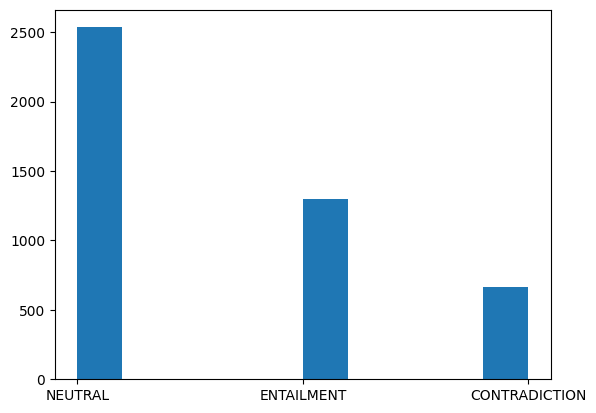

In [ ]:
plt.hist(dataset['entailment_judgment'])

In [9]:
map_entailement = {'ENTAILMENT': 0, 'NEUTRAL': 1, 'CONTRADICTION': 2}
dataset['entailment_judgment'] = dataset['entailment_judgment'].map(map_entailement)

In [10]:
np.unique(dataset["entailment_judgment"], return_counts= True)

(array([0, 1, 2]), array([1299, 2536,  665]))

In [11]:
dataset.head()

,pair_ID,sentence_A,sentence_B,relatedness_score,entailment_judgment
0,1,A group of kids is playing in a yard and an ol...,A group of boys in a yard is playing and a man...,4.5,1
1,2,A group of children is playing in the house an...,A group of kids is playing in a yard and an ol...,3.2,1
2,3,The young boys are playing outdoors and the ma...,The kids are playing outdoors near a man with ...,4.7,0
3,5,The kids are playing outdoors near a man with ...,A group of kids is playing in a yard and an ol...,3.4,1
4,9,The young boys are playing outdoors and the ma...,A group of kids is playing in a yard and an ol...,3.7,1


In [12]:
dataset.to_csv('data/sick_clean.csv', index=False)

In [17]:
dataset.shape


(4500, 5)